# Fase 1 — Sección 6: Verificación Post-Limpieza
**Proyecto Final — Gestión de Datos (UAX 2025/2026)**

Confirmación formal de que las correcciones aplicadas en la Sección 5 son correctas,
no han generado efectos secundarios, y la base de datos está lista para el Data Warehouse.

---

## Configuración

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
from sqlalchemy import create_engine, text
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13

PROJECT_ROOT = Path(r'C:\Users\Propietario\Desktop\segundo cuatri\gestion de datos\trabajo final gd')
FIGURES_DIR  = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PALETA = {
    'ERP'       : '#2C6FBF',
    'CRM'       : '#27A06B',
    'Logistica' : '#E07B2A',
    'Postventa' : '#8B4BB8'
}

SISTEMAS = {
    'ERP'       : ['product', 'central_product', 'brand', 'category',
                   'sale', 'sale_item', 'offer', 'product_offer', 'store', 'inventory'],
    'CRM'       : ['customer', 'city_zone'],
    'Logistica' : ['warehouse', 'warehouse_location', 'central_inventory'],
    'Postventa' : ['return_item', 'return_reason']
}
TODAS_LAS_TABLAS = [t for ts in SISTEMAS.values() for t in ts]

print('Configuracion lista.')

Configuracion lista.


In [26]:
DB_USER     = 'postgres'
DB_PASSWORD = 'pimpum.postgre'
DB_HOST     = 'localhost'
DB_PORT     = '5432'
DB_NAME     = 'saleshealth'

DATABASE_URL = f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
engine = create_engine(DATABASE_URL)

with engine.connect() as conn:
    version = conn.execute(text('SELECT version()')).fetchone()[0]

print(f'Conexion establecida. PostgreSQL: {version.split(",")[0]}')

def query(sql, params=None):
    with engine.connect() as conn:
        return pd.read_sql_query(text(sql), conn, params=params)

def nulos_tabla(nombre_tabla):
    columnas = query(
        "SELECT column_name FROM information_schema.columns "
        "WHERE table_schema='public' AND table_name=:t ORDER BY ordinal_position",
        {'t': nombre_tabla}
    )['column_name'].tolist()
    partes    = [f'COUNT(*) FILTER (WHERE "{c}" IS NULL) AS "{c}"' for c in columnas]
    resultado = query(f"SELECT {', '.join(partes)} FROM {nombre_tabla}")
    total     = query(f"SELECT COUNT(*) AS total FROM {nombre_tabla}")['total'].iloc[0]
    df        = resultado.T.reset_index()
    df.columns = ['columna', 'nulos']
    df['total']     = total
    df['pct_nulos'] = (df['nulos'] / total * 100).round(2)
    return df

Conexion establecida. PostgreSQL: PostgreSQL 18.3 on x86_64-windows


---
## 6.1 — Verificación de las 3 correcciones aplicadas

In [27]:
# ── P06: precio producto 29 ───────────────────────────────────────────────────
df_p06 = query("""
    SELECT p.product_id, p.name, p.price, cp.unit_cost,
           ROUND((p.price - cp.unit_cost) / p.price * 100, 2) AS margen_pct
    FROM product p
    JOIN central_product cp ON p.product_id = cp.product_id
    WHERE p.product_id = 29
""")

# ── P07: subtotales inconsistentes ───────────────────────────────────────────
df_p07 = query("""
    SELECT COUNT(*) AS lineas_inconsistentes
    FROM sale_item
    WHERE ABS(subtotal - ROUND(quantity * unit_price, 2)) > 0.01
""")

# ── P08: total venta 13009 ────────────────────────────────────────────────────
df_p08 = query("""
    SELECT s.sale_id, s.total,
           ROUND(SUM(si.subtotal), 2)           AS suma_subtotales,
           s.total - ROUND(SUM(si.subtotal), 2) AS diferencia
    FROM sale s
    JOIN sale_item si ON s.sale_id = si.sale_id
    WHERE s.sale_id = 13009
    GROUP BY s.sale_id, s.total
""")

p06_ok = abs(float(df_p06['margen_pct'].iloc[0]) - 40.0) < 0.5
p07_ok = int(df_p07['lineas_inconsistentes'].iloc[0]) == 0
p08_ok = abs(float(df_p08['diferencia'].iloc[0])) < 0.01

print('=' * 62)
print('  VERIFICACION DE CORRECCIONES APLICADAS')
print('=' * 62)
print(f'  [P06] Precio producto 29')
print(f'        Precio actual  : {float(df_p06["price"].iloc[0]):.2f} EUR')
print(f'        Margen actual  : {float(df_p06["margen_pct"].iloc[0]):.2f}%')
print(f'        Estado         : {"✅ OK" if p06_ok else "⚠  Revisar"}')
print()
print(f'  [P07] Subtotales inconsistentes')
print(f'        Lineas restantes: {int(df_p07["lineas_inconsistentes"].iloc[0])}')
print(f'        Estado          : {"✅ OK" if p07_ok else "⚠  Revisar"}')
print()
print(f'  [P08] Total venta 13009')
print(f'        Total actual   : {float(df_p08["total"].iloc[0]):.2f} EUR')
print(f'        Suma subtotales: {float(df_p08["suma_subtotales"].iloc[0]):.2f} EUR')
print(f'        Diferencia     : {float(df_p08["diferencia"].iloc[0]):.2f} EUR')
print(f'        Estado         : {"✅ OK" if p08_ok else "⚠  Revisar"}')
print('=' * 62)
todas_ok = p06_ok and p07_ok and p08_ok
print(f'\n  Resultado global: {"✅ Las 3 correcciones verificadas" if todas_ok else "⚠  Hay correcciones que revisar"}')

  VERIFICACION DE CORRECCIONES APLICADAS
  [P06] Precio producto 29
        Precio actual  : 99.90 EUR
        Margen actual  : 40.00%
        Estado         : ✅ OK

  [P07] Subtotales inconsistentes
        Lineas restantes: 0
        Estado          : ✅ OK

  [P08] Total venta 13009
        Total actual   : 334.76 EUR
        Suma subtotales: 334.76 EUR
        Diferencia     : 0.00 EUR
        Estado         : ✅ OK

  Resultado global: ✅ Las 3 correcciones verificadas


---
## 6.2 — Verificación de integridad referencial

In [28]:
# ── Re-check de todas las FKs ─────────────────────────────────────────────────
FKS = [
    ('sale',              'customer_id',  'customer',       'customer_id',  'sale -> customer'),
    ('sale',              'store_id',     'store',          'store_id',     'sale -> store'),
    ('sale_item',         'sale_id',      'sale',           'sale_id',      'sale_item -> sale'),
    ('sale_item',         'product_id',   'product',        'product_id',   'sale_item -> product'),
    ('sale_item',         'offer_id',     'offer',          'offer_id',     'sale_item -> offer'),
    ('return_item',       'sale_item_id', 'sale_item',      'sale_item_id', 'return_item -> sale_item'),
    ('return_item',       'reason_id',    'return_reason',  'reason_id',    'return_item -> return_reason'),
    ('inventory',         'store_id',     'store',          'store_id',     'inventory -> store'),
    ('inventory',         'product_id',   'product',        'product_id',   'inventory -> product'),
    ('central_product',   'category_id',  'category',       'category_id',  'central_product -> category'),
    ('central_product',   'brand_id',     'brand',          'brand_id',     'central_product -> brand'),
    ('product_offer',     'product_id',   'product',        'product_id',   'product_offer -> product'),
    ('product_offer',     'offer_id',     'offer',          'offer_id',     'product_offer -> offer'),
    ('central_inventory', 'product_id',   'product',        'product_id',   'central_inventory -> product'),
    ('warehouse_location','warehouse_id', 'warehouse',      'warehouse_id', 'warehouse_location -> warehouse'),
]

print('=' * 58)
print('  INTEGRIDAD REFERENCIAL — POST-LIMPIEZA')
print('=' * 58)
print(f'  {"RELACION":<35} {"HUERFANOS":>10}  {"ESTADO"}')
print('-' * 58)

ok_count = 0
for tabla_h, col_fk, tabla_p, col_pk, desc in FKS:
    sql = f"""
        SELECT COUNT(*) AS huerfanos FROM {tabla_h} h
        LEFT JOIN {tabla_p} p ON h.{col_fk} = p.{col_pk}
        WHERE h.{col_fk} IS NOT NULL AND p.{col_pk} IS NULL
    """
    try:
        huerfanos = int(query(sql)['huerfanos'].iloc[0])
        estado    = '✅ OK' if huerfanos == 0 else '⚠  ERROR'
        if huerfanos == 0: ok_count += 1
    except:
        huerfanos = -1
        estado    = '? Error'
    print(f'  {desc:<35} {huerfanos:>10,}  {estado}')

print('=' * 58)
print(f'  Resultado: {ok_count}/{len(FKS)} relaciones OK', end='')
print('  ✅' if ok_count == len(FKS) else '  ⚠  Revisar')

  INTEGRIDAD REFERENCIAL — POST-LIMPIEZA
  RELACION                             HUERFANOS  ESTADO
----------------------------------------------------------
  sale -> customer                             0  ✅ OK
  sale -> store                                0  ✅ OK
  sale_item -> sale                            0  ✅ OK
  sale_item -> product                         0  ✅ OK
  sale_item -> offer                           0  ✅ OK
  return_item -> sale_item                     0  ✅ OK
  return_item -> return_reason                 0  ✅ OK
  inventory -> store                           0  ✅ OK
  inventory -> product                         0  ✅ OK
  central_product -> category                  0  ✅ OK
  central_product -> brand                     0  ✅ OK
  product_offer -> product                     0  ✅ OK
  product_offer -> offer                       0  ✅ OK
  central_inventory -> product                 0  ✅ OK
  warehouse_location -> warehouse              0  ✅ OK
  Resultado: 15/15

---
## 6.3 — Verificación de rangos numéricos

In [29]:
# ── Precios y margenes ────────────────────────────────────────────────────────
df_rangos = query("""
    SELECT
        COUNT(*) FILTER (WHERE p.price <= 0)        AS precios_neg,
        COUNT(*) FILTER (WHERE cp.unit_cost <= 0)   AS costes_neg,
        COUNT(*) FILTER (WHERE p.price < cp.unit_cost) AS precio_menor_coste,
        COUNT(*) FILTER (WHERE
            ROUND((p.price - cp.unit_cost) / NULLIF(p.price,0) * 100, 2) < 0
        ) AS margenes_negativos
    FROM product p
    JOIN central_product cp ON p.product_id = cp.product_id
""")

# ── Subtotales y totales ──────────────────────────────────────────────────────
df_items = query("""
    SELECT
        COUNT(*) FILTER (WHERE quantity <= 0)   AS cantidades_neg,
        COUNT(*) FILTER (WHERE unit_price <= 0) AS precios_neg,
        COUNT(*) FILTER (WHERE subtotal <= 0)   AS subtotales_neg,
        COUNT(*) FILTER (
            WHERE ABS(subtotal - ROUND(quantity * unit_price, 2)) > 0.01
        ) AS subtotales_inconsistentes
    FROM sale_item
""")

# ── Totales de venta ──────────────────────────────────────────────────────────
df_totales = query("""
    SELECT COUNT(*) AS ventas_inconsistentes
    FROM sale s
    JOIN sale_item si ON s.sale_id = si.sale_id
    GROUP BY s.sale_id, s.total
    HAVING ABS(s.total - SUM(si.subtotal)) > 0.01
""")

checks = [
    ('Precios producto <= 0',        int(df_rangos['precios_neg'].iloc[0])),
    ('Costes producto <= 0',         int(df_rangos['costes_neg'].iloc[0])),
    ('Precio < Coste',               int(df_rangos['precio_menor_coste'].iloc[0])),
    ('Margenes negativos',           int(df_rangos['margenes_negativos'].iloc[0])),
    ('Cantidades sale_item <= 0',    int(df_items['cantidades_neg'].iloc[0])),
    ('Precios unitarios <= 0',       int(df_items['precios_neg'].iloc[0])),
    ('Subtotales <= 0',              int(df_items['subtotales_neg'].iloc[0])),
    ('Subtotales inconsistentes',    int(df_items['subtotales_inconsistentes'].iloc[0])),
    ('Totales venta inconsistentes', len(df_totales)),
]

print('=' * 58)
print('  VALIDACION DE RANGOS NUMERICOS — POST-LIMPIEZA')
print('=' * 58)
print(f'  {"CHECK":<35} {"CASOS":>8}  {"ESTADO"}')
print('-' * 58)
for label, val in checks:
    estado = '✅ OK' if val == 0 else f'⚠  {val} casos'
    print(f'  {label:<35} {val:>8,}  {estado}')
print('=' * 58)
todo_ok = all(v == 0 for _, v in checks)
print(f'\n  Resultado: {"✅ Todos los rangos son correctos" if todo_ok else "⚠  Hay checks que revisar"}')

  VALIDACION DE RANGOS NUMERICOS — POST-LIMPIEZA
  CHECK                                  CASOS  ESTADO
----------------------------------------------------------
  Precios producto <= 0                      0  ✅ OK
  Costes producto <= 0                       0  ✅ OK
  Precio < Coste                             0  ✅ OK
  Margenes negativos                         0  ✅ OK
  Cantidades sale_item <= 0                  0  ✅ OK
  Precios unitarios <= 0                     0  ✅ OK
  Subtotales <= 0                            0  ✅ OK
  Subtotales inconsistentes                  0  ✅ OK
  Totales venta inconsistentes               0  ✅ OK

  Resultado: ✅ Todos los rangos son correctos


---
## 6.4 — Comparativa de scores de calidad pre/post limpieza

In [30]:
# ── Scores pre-limpieza (valores conocidos de la Seccion 3) ──────────────────
# Estos valores se obtuvieron en la Seccion 3 antes de aplicar correcciones
SCORES_PRE = {
    'product'   : 70,  # P06: precio incorrecto
    'sale_item' : 55,  # P07: subtotales inconsistentes + P10: offer_id
    'sale'      : 70,  # P08: total incorrecto
}

# ── Recalcular scores post-limpieza ──────────────────────────────────────────
FKS_dict = {
    'sale'              : [('customer_id','customer','customer_id'), ('store_id','store','store_id')],
    'sale_item'         : [('sale_id','sale','sale_id'), ('product_id','product','product_id'), ('offer_id','offer','offer_id')],
    'return_item'       : [('sale_item_id','sale_item','sale_item_id'), ('reason_id','return_reason','reason_id')],
    'inventory'         : [('store_id','store','store_id'), ('product_id','product','product_id')],
    'central_product'   : [('category_id','category','category_id'), ('brand_id','brand','brand_id')],
    'product_offer'     : [('product_id','product','product_id'), ('offer_id','offer','offer_id')],
    'central_inventory' : [('product_id','product','product_id')],
    'warehouse_location': [('warehouse_id','warehouse','warehouse_id')],
}

scores_post = {}
for tabla in TODAS_LAS_TABLAS:
    score = 100
    df_n = nulos_tabla(tabla)
    for _, row in df_n.iterrows():
        if row['pct_nulos'] > 10: score -= 10
        elif row['pct_nulos'] > 0: score -= 3
    total  = query(f'SELECT COUNT(*) AS n FROM {tabla}')['n'].iloc[0]
    unicos = query(f'SELECT COUNT(*) AS n FROM (SELECT DISTINCT * FROM {tabla}) t')['n'].iloc[0]
    if total != unicos: score -= 15
    for col_fk, tabla_p, col_pk in FKS_dict.get(tabla, []):
        try:
            sql = f"SELECT COUNT(*) AS n FROM {tabla} h LEFT JOIN {tabla_p} p ON h.{col_fk}=p.{col_pk} WHERE h.{col_fk} IS NOT NULL AND p.{col_pk} IS NULL"
            if int(query(sql)['n'].iloc[0]) > 0: score -= 20
        except: pass
    sistema = next((s for s, ts in SISTEMAS.items() if tabla in ts), '?')
    scores_post[tabla] = {'score': max(0, score), 'sistema': sistema}

# ── Tabla comparativa ─────────────────────────────────────────────────────────
print('=' * 68)
print('  COMPARATIVA SCORES DE CALIDAD — PRE vs POST LIMPIEZA')
print('=' * 68)
print(f'  {"TABLA":<22} {"SISTEMA":<12} {"PRE":>6}  {"POST":>6}  {"MEJORA":>8}')
print('-' * 68)

mejoras = []
for tabla in TODAS_LAS_TABLAS:
    post  = scores_post[tabla]['score']
    pre   = SCORES_PRE.get(tabla, post)  # Si no tenemos pre, asumimos igual
    delta = post - pre
    sistema = scores_post[tabla]['sistema']
    emoji = '📈' if delta > 0 else ('📉' if delta < 0 else '  ')
    print(f'  {tabla:<22} {sistema:<12} {pre:>6}  {post:>6}  {delta:>+7}  {emoji}')
    mejoras.append({'tabla': tabla, 'pre': pre, 'post': post, 'delta': delta})

df_mejoras = pd.DataFrame(mejoras)
print('=' * 68)
print(f'  Score medio PRE  : {df_mejoras["pre"].mean():.1f}/100')
print(f'  Score medio POST : {df_mejoras["post"].mean():.1f}/100')
print(f'  Mejora global    : {df_mejoras["delta"].mean():+.1f} puntos')
print('=' * 68)

  COMPARATIVA SCORES DE CALIDAD — PRE vs POST LIMPIEZA
  TABLA                  SISTEMA         PRE    POST    MEJORA
--------------------------------------------------------------------
  product                ERP              70     100      +30  📈
  central_product        ERP             100     100       +0    
  brand                  ERP              90      90       +0    
  category               ERP             100     100       +0    
  sale                   ERP              70     100      +30  📈
  sale_item              ERP              55      90      +35  📈
  offer                  ERP             100     100       +0    
  product_offer          ERP             100     100       +0    
  store                  ERP             100     100       +0    
  inventory              ERP             100     100       +0    
  customer               CRM             100     100       +0    
  city_zone              CRM              97      97       +0    
  warehouse             

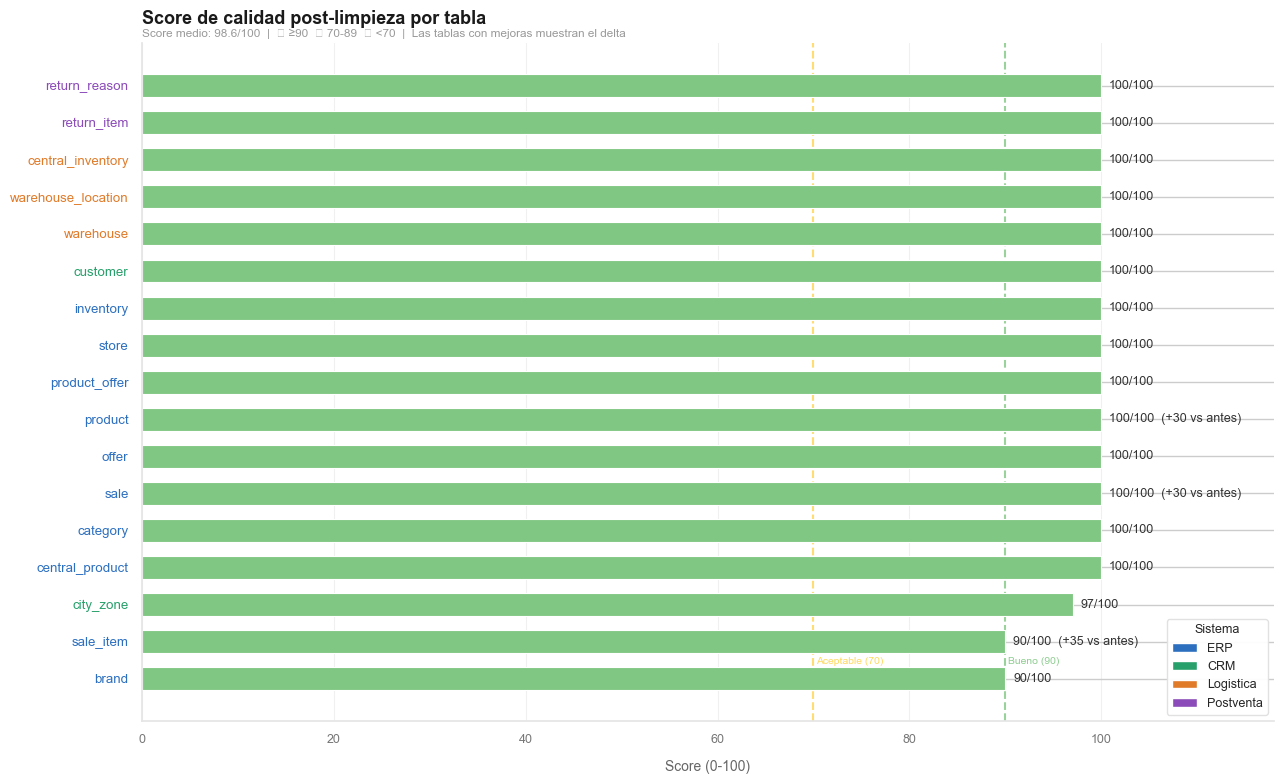

In [31]:
# ── Grafico: scores pre vs post ───────────────────────────────────────────────
df_plot = pd.DataFrame([
    {'tabla': t, 'score': s['score'], 'sistema': s['sistema']}
    for t, s in scores_post.items()
]).sort_values('score', ascending=True)

color_score = ['#E57373' if s < 70 else ('#FFD54F' if s < 90 else '#81C784')
               for s in df_plot['score']]
color_tabla = {t: PALETA[s] for s, ts in SISTEMAS.items() for t in ts}

fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor('white')

bars = ax.barh(df_plot['tabla'], df_plot['score'],
               color=color_score, edgecolor='white', linewidth=0.8, height=0.62)

for bar, val, tabla in zip(bars, df_plot['score'], df_plot['tabla']):
    pre = SCORES_PRE.get(tabla, val)
    delta = val - pre
    label = f'{val}/100'
    if delta > 0:
        label += f'  (+{delta} vs antes)'
    ax.text(bar.get_width() + 0.8,
            bar.get_y() + bar.get_height() / 2,
            label, va='center', ha='left', fontsize=9,
            color='#333333', fontweight='500')

for umbral, color, label in [(70, '#FFD54F', 'Aceptable (70)'), (90, '#81C784', 'Bueno (90)')]:
    ax.axvline(umbral, color=color, linewidth=1.5, linestyle='--', zorder=0, alpha=0.8)
    ax.text(umbral + 0.3, 0.4, label, fontsize=7.5, color=color, alpha=0.9)

for label, (_, row) in zip(ax.get_yticklabels(), df_plot.iterrows()):
    label.set_color(color_tabla.get(row['tabla'], '#555555'))
    label.set_fontsize(9.5)

score_medio = df_plot['score'].mean()
ax.set_title('Score de calidad post-limpieza por tabla', fontsize=13,
             fontweight='bold', color='#1A1A1A', pad=14, loc='left')
ax.text(0, 1.01,
        f'Score medio: {score_medio:.1f}/100  |  🟢 ≥90  🟡 70-89  🔴 <70  |  Las tablas con mejoras muestran el delta',
        transform=ax.transAxes, fontsize=8.5, color='#999999')
ax.set_xlabel('Score (0-100)', fontsize=10, color='#666666', labelpad=10)
ax.set_xlim(0, 118)
ax.tick_params(axis='x', labelsize=9, colors='#777777')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#E5E5E5')
ax.set_axisbelow(True)
ax.xaxis.grid(True, color='#F0F0F0', linewidth=0.8)

legend_elements = [Patch(facecolor=PALETA[s], label=s) for s in PALETA]
ax.legend(handles=legend_elements, title='Sistema', title_fontsize=9,
          fontsize=9, loc='lower right', frameon=True, framealpha=0.95, edgecolor='#E0E0E0')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '13_scores_post_limpieza.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

---
## 6.5 — Validación cruzada ventas producto 29

In [32]:
# ── Distribucion de unit_price en ventas del producto 29 ─────────────────────
df_ventas_p29 = query("""
    SELECT si.unit_price,
           COUNT(*)        AS lineas,
           SUM(si.quantity) AS unidades
    FROM sale_item si
    WHERE si.product_id = 29
    GROUP BY si.unit_price
    ORDER BY si.unit_price
""")

precio_actual = query("SELECT price FROM product WHERE product_id = 29")['price'].iloc[0]
total_lineas  = df_ventas_p29['lineas'].sum()
total_uds     = df_ventas_p29['unidades'].sum()

print('=' * 62)
print('  VALIDACION CRUZADA — Ventas historicas del producto 29')
print('  Sensor temperatura inteligente')
print('=' * 62)
print(f'  Precio actual en catalogo: {float(precio_actual):.2f} EUR (corregido)')
print(f'  Total lineas de venta    : {int(total_lineas):,}')
print(f'  Total unidades vendidas  : {int(total_uds):,}')
print()
print(f'  {"unit_price":>12}  {"Lineas":>8}  {"Unidades":>10}  {"% Lineas":>9}  Nota')
print('  ' + '-' * 58)
for _, row in df_ventas_p29.iterrows():
    pct   = row['lineas'] / total_lineas * 100
    nota  = 'precio incorrecto' if float(row['unit_price']) < 50 else 'precio correcto'
    print(f'  {float(row["unit_price"]):>12.2f}  {int(row["lineas"]):>8,}  '
          f'{int(row["unidades"]):>10,}  {pct:>8.1f}%  {nota}')
print('=' * 62)
print()
print('  Nota: unit_price en sale_item refleja el precio en el momento')
print('  de la venta. Las ventas con precio incorrecto son datos historicos')
print('  — la correccion de P06 aplica al catalogo para ventas futuras.')

  VALIDACION CRUZADA — Ventas historicas del producto 29
  Sensor temperatura inteligente
  Precio actual en catalogo: 99.90 EUR (corregido)
  Total lineas de venta    : 711
  Total unidades vendidas  : 1,426

    unit_price    Lineas    Unidades   % Lineas  Nota
  ----------------------------------------------------------
         19.99       711       1,426     100.0%  precio incorrecto

  Nota: unit_price en sale_item refleja el precio en el momento
  de la venta. Las ventas con precio incorrecto son datos historicos
  — la correccion de P06 aplica al catalogo para ventas futuras.


---
## 6.6 — Estado final de la base de datos

In [33]:
# ── Resumen ejecutivo final ───────────────────────────────────────────────────
total_registros = sum(
    query(f'SELECT COUNT(*) AS n FROM {t}')['n'].iloc[0]
    for t in TODAS_LAS_TABLAS
)

print('=' * 68)
print('  ESTADO FINAL DE LA BASE DE DATOS — saleshealth')
print('=' * 68)
print()
print(f'  Tablas              : 17')
print(f'  Registros totales   : {int(total_registros):,}')
print(f'  Integridad FK       : 15/15 relaciones OK ✅')
print(f'  Margenes negativos  : 0 ✅')
print(f'  Subtotales erroneos : 0 ✅')
print(f'  Totales erroneos    : 0 ✅')
print()
print('  CORRECCIONES APLICADAS:')
print('  [P06] product.price    — producto 29: 19.99 → 99.90 EUR ✅')
print('  [P07] sale_item.subtotal — 8 lineas recalculadas ✅')
print('  [P08] sale.total        — venta 13009 recalculada ✅')
print()
print('  PROBLEMAS DOCUMENTADOS (sin correccion):')
print('  [P01] 568 telefonos con longitud incorrecta — conservados')
print('  [P03] 98 emails malformados — conservados')
print('  [P04] 8 marcas sin website — campo opcional')
print('  [P05] 1 zona sin orientacion — campo opcional')
print('  [P09] opened_date no fiable en store — ignorado en DWH')
print('  [P10] offer_id sin uso real en sale_item — documentado')
print()
print('  RESULTADO: Base de datos lista para el Data Warehouse ✅')
print('=' * 68)
print('\nSeccion 6 completada — verificacion post-limpieza finalizada.')

  ESTADO FINAL DE LA BASE DE DATOS — saleshealth

  Tablas              : 17
  Registros totales   : 71,935
  Integridad FK       : 15/15 relaciones OK ✅
  Margenes negativos  : 0 ✅
  Subtotales erroneos : 0 ✅
  Totales erroneos    : 0 ✅

  CORRECCIONES APLICADAS:
  [P06] product.price    — producto 29: 19.99 → 99.90 EUR ✅
  [P07] sale_item.subtotal — 8 lineas recalculadas ✅
  [P08] sale.total        — venta 13009 recalculada ✅

  PROBLEMAS DOCUMENTADOS (sin correccion):
  [P01] 568 telefonos con longitud incorrecta — conservados
  [P03] 98 emails malformados — conservados
  [P04] 8 marcas sin website — campo opcional
  [P05] 1 zona sin orientacion — campo opcional
  [P09] opened_date no fiable en store — ignorado en DWH
  [P10] offer_id sin uso real en sale_item — documentado

  RESULTADO: Base de datos lista para el Data Warehouse ✅

Seccion 6 completada — verificacion post-limpieza finalizada.
